# Data Analysis Notebook
## House price Dataset Analysis

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display plots inside Jupyter Notebook
%matplotlib inline

# Optional: Improve plot appearance
sns.set_style('whitegrid')

## Load dataset

In [2]:
df = pd.read_csv(r"C:\Users\HP\Desktop\Pro\dataset\Housing.csv")

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
print("Shape:", df.shape)

Shape: (545, 13)


In [18]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Univariate Analysis

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Key Observations from Descriptive Statistics

- The average house price is approximately **4.77 million**.
- The average house area is approximately **5,150 square units**.
- Most houses have **3 bedrooms** and **1–2 bathrooms**.
- The majority of houses have **1–2 stories**.
- Parking availability ranges from **0 to 3 spaces**.
- House **price** and **area** exhibit high variability, suggesting substantial differences among properties and indicating that these features may strongly influence house prices.

In [7]:
df.duplicated().sum()

np.int64(0)

* **No duplicate records** were found in the dataset. Therefore, no duplicate removal was required.

In [8]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

### Dataset Variable Overview

* **Numerical Variables (6):** `price`, `area`, `bedrooms`, `bathrooms`, `stories`, `parking`
* **Categorical Variables (7):** `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`, `furnishingstatus`

#### Data Integrity Notes
* **Data Types:** All columns have appropriate data types. 
* **Storage Formats:** Numerical features are stored as integers (`int64`); categorical features are stored as objects (`object`).
* **Cleaning Impact:** No data type conversion was required during the data cleaning process.


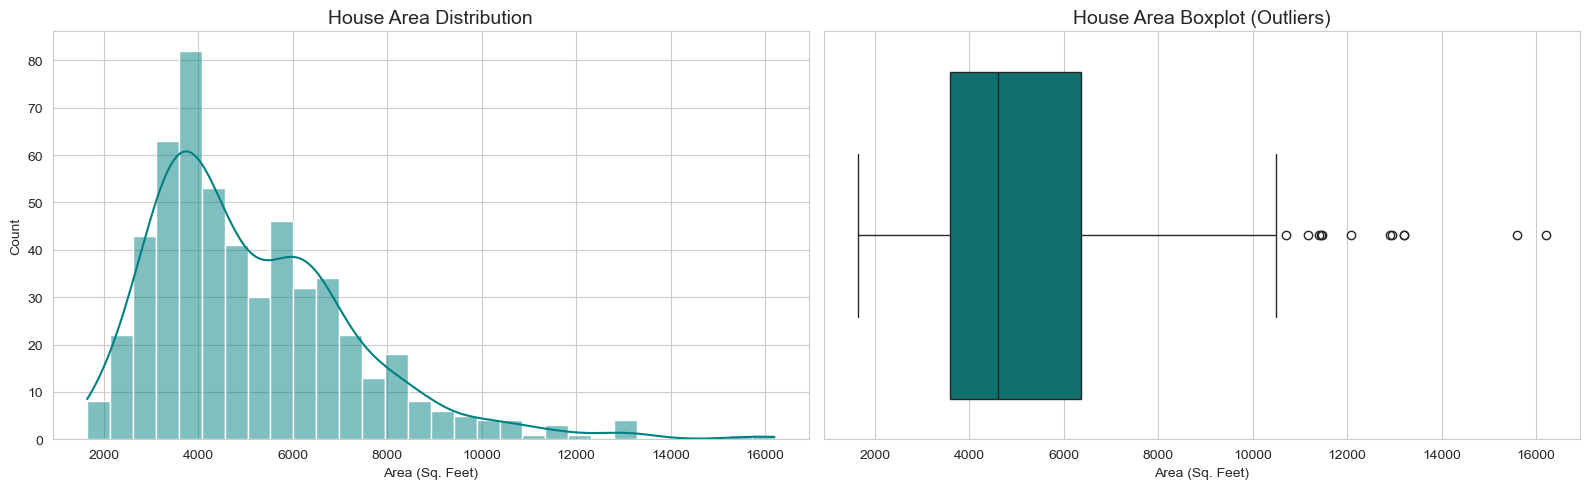

In [9]:
# House Area Distribution & Outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['area'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('House Area Distribution', fontsize=14)
axes[0].set_xlabel('Area (Sq. Feet)')

sns.boxplot(x=df['area'], ax=axes[1], color='teal')
axes[1].set_title('House Area Boxplot (Outliers)', fontsize=14)
axes[1].set_xlabel('Area (Sq. Feet)')

plt.tight_layout()
plt.show()

### House Area Distribution & Outlier Analysis

* **Distribution Shape:** Highly **right-skewed** (positively skewed).
* **Concentration:** Most properties fall between **3,000 and 5,000 sq. feet**, peaking around 4,000 sq. feet.
* **Core Market (IQR):** The middle 50% of homes range from roughly **3,600 to 6,300 sq. feet** (median just under 5,000 sq. feet).
* **Outliers:** Significant upper-bound outliers exist beyond **10,500 sq. feet**, with extreme property sizes reaching over **16,000 sq. feet**.


## Bedrooms Distribution

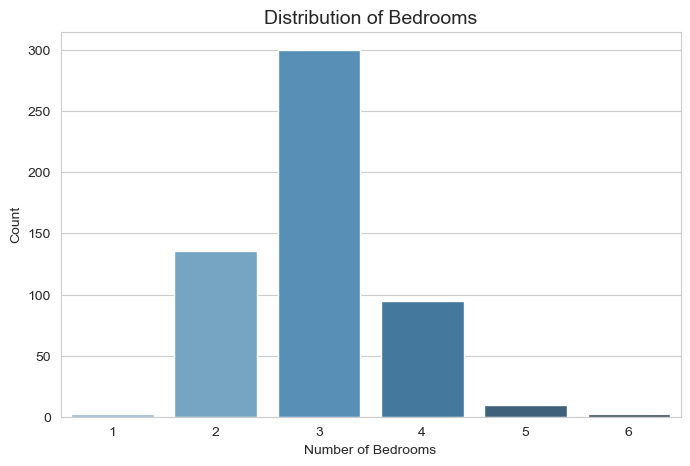

In [10]:
# Frequency count of Bedrooms
plt.figure(figsize=(8, 5))
sns.countplot(x='bedrooms', data=df, palette='Blues_d')
plt.title('Distribution of Bedrooms', fontsize=14)
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.show()

### Distribution of Bedrooms

* **Mode:** **3-bedroom** homes dominate the dataset with a peak count of **300**.
* **Majority:** Most properties consist of **2, 3, or 4 bedrooms**.
* **Rarities:** **1, 5, and 6-bedroom** homes are extremely rare.
* **Shape:** Unimodal distribution centered around 3 bedrooms.



## Bathrooms Distribution

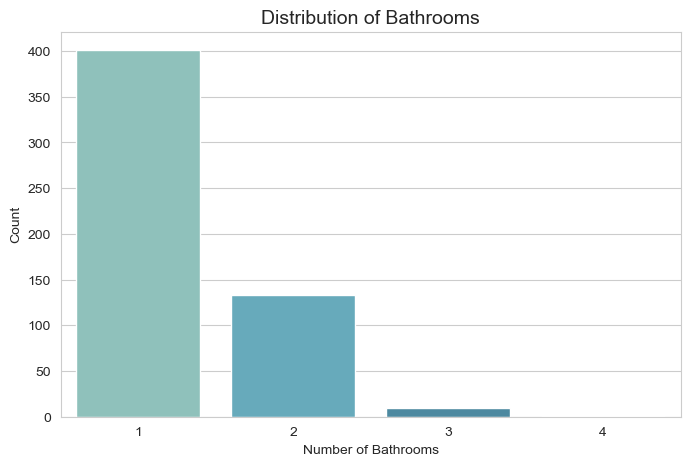

In [11]:
# Frequency count of Bathrooms
plt.figure(figsize=(8, 5))
sns.countplot(x='bathrooms', data=df, palette='GnBu_d')
plt.title('Distribution of Bathrooms', fontsize=14)
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.show()

### Distribution of Bathrooms

* **Mode:** **1-bathroom** homes heavily dominate the dataset with a count of **400**.
* **Majority:** Almost all properties contain either **1 or 2 bathrooms**.
* **Rarities:** Homes with **3 or 4 bathrooms** are exceptionally rare.
* **Shape:** Strongly **right-skewed** distribution.


## Stories Distribution

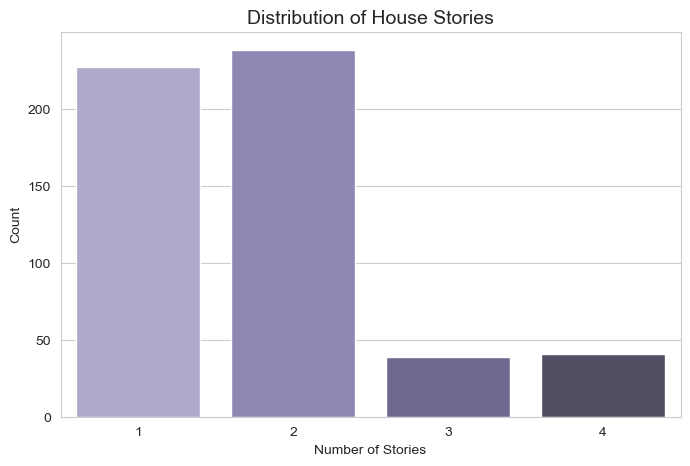

In [12]:
# Frequency count of Stories
plt.figure(figsize=(8, 5))
sns.countplot(x='stories', data=df, palette='Purples_d')
plt.title('Distribution of House Stories', fontsize=14)
plt.xlabel('Number of Stories')
plt.ylabel('Count')
plt.show()

### Distribution of House Stories

* **Mode:** **2-story** homes are the most frequent, closely followed by **1-story** properties.
* **Concentration:** The vast majority of the dataset consists of **1 and 2-story** homes (each over 225 counts).
* **Drop-off:** A steep decline occurs for taller structures, with **3 and 4-story** homes being much less common (under 50 counts each).
* **Shape:** Strongly **right-skewed** categorical distribution.


## Parking Spaces Distribution

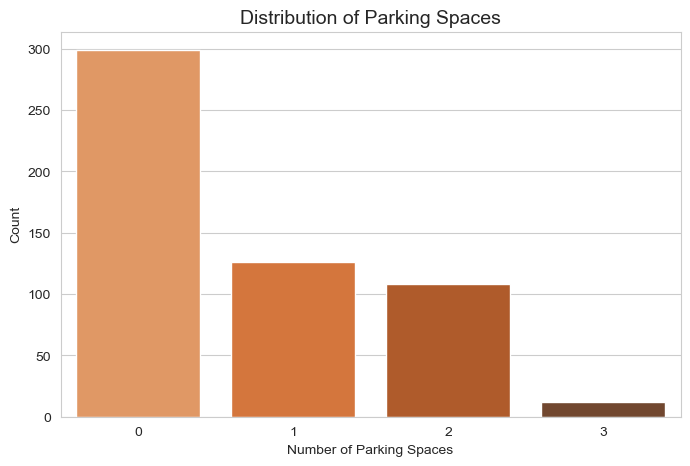

In [13]:
# Frequency count of Parking Spaces
plt.figure(figsize=(8, 5))
sns.countplot(x='parking', data=df, palette='Oranges_d')
plt.title('Distribution of Parking Spaces', fontsize=14)
plt.xlabel('Number of Parking Spaces')
plt.ylabel('Count')
plt.show()

### Distribution of Parking Spaces

* **Mode:** **0 parking spaces** heavily dominates the dataset, reaching nearly **300 homes**.
* **Mid-Range:** Properties with **1 or 2 parking spaces** show similar frequencies (around 110–125 counts each).
* **Rarity:** Homes with **3 parking spaces** are exceptionally rare (under 15 counts).
* **Shape:** Strongly **right-skewed** distribution showing a steady decline as parking capacity increases.


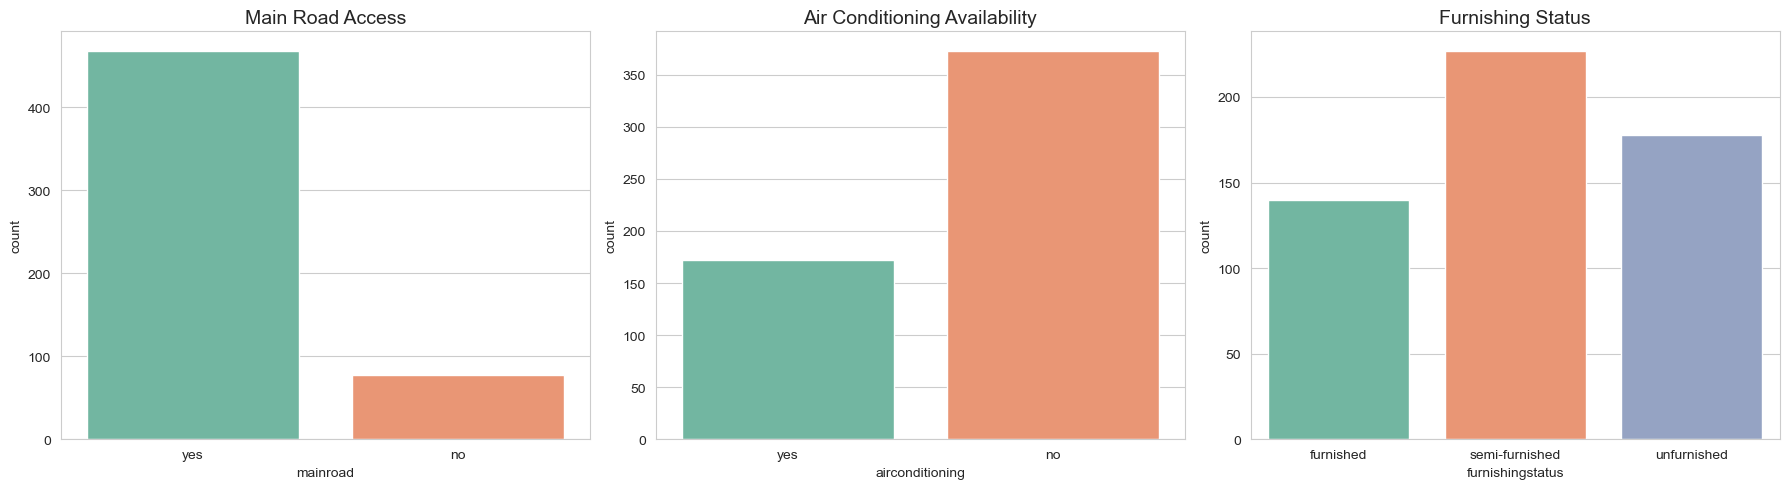

In [14]:
# Distribution of key categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='mainroad', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Main Road Access', fontsize=14)

sns.countplot(x='airconditioning', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Air Conditioning Availability', fontsize=14)

sns.countplot(x='furnishingstatus', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Furnishing Status', fontsize=14)

plt.tight_layout()
plt.show()

### Categorical Variables Distribution Analysis

* **Main Road Access:** The vast majority of properties (over 450) have access to a main road, while fewer than 100 properties do not.
* **Air Conditioning Availability:** Most homes (roughly 370) **do not** have air conditioning, outnumbering those with AC (around 170) by more than 2 to 1.
* **Furnishing Status:** **Semi-furnished** is the most common status (over 220 properties), followed by unfurnished properties (~175) and furnished properties (~140).


## Price vs. Area

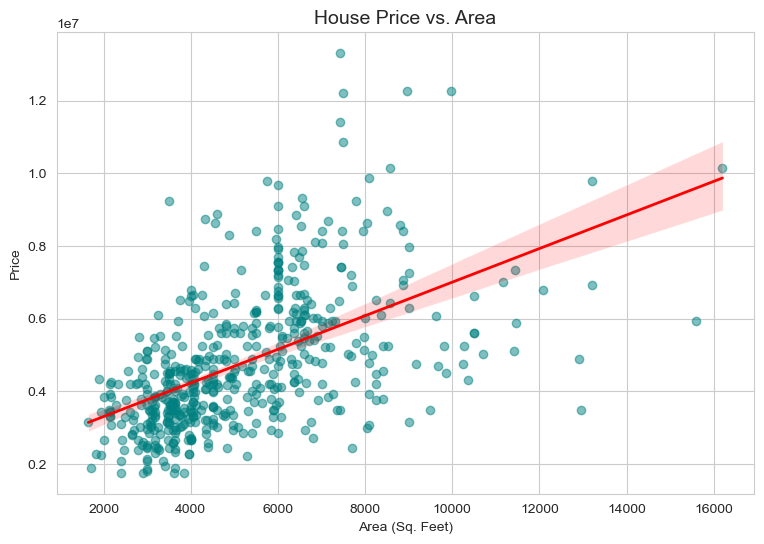

In [15]:
# Investigating the continuous relationship between Area and Price
plt.figure(figsize=(9, 6))
sns.regplot(x='area', y='price', data=df, 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title('House Price vs. Area', fontsize=14)
plt.xlabel('Area (Sq. Feet)')
plt.ylabel('Price')
plt.show()

### House Price vs. Area Bivariate Analysis

* **Correlation:** Shows a clear, strong **positive linear relationship** between property area and house price.
* **Trendline:** The red regression line confirms that as house square footage increases, the price consistently rises.
* **Density:** Property data points are heavily concentrated between **2,000 and 6,000 sq. feet**, ranging in price from \$2M to \$6M.
* **Outliers:** Several high-priced properties (\$10M+) exist around the 7,000–10,000 sq. feet range, deviating significantly above the average trend.


## Price vs. Bedrooms

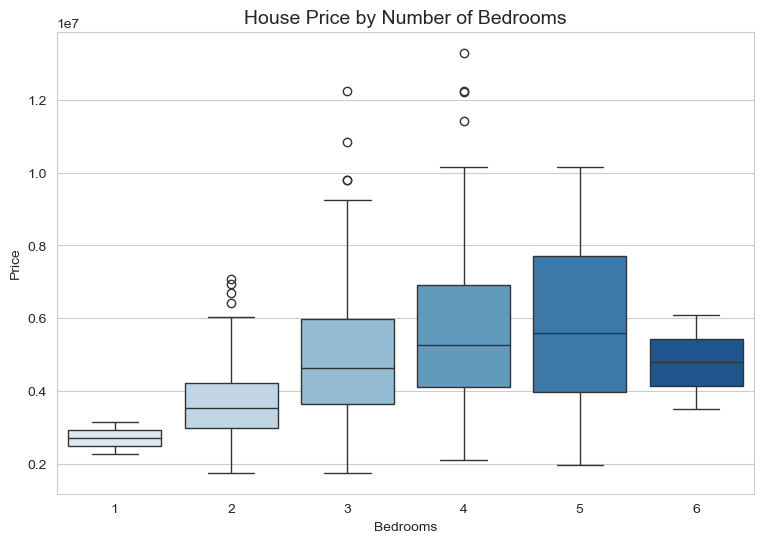

In [16]:
# Analyzing how the number of bedrooms affects property value
plt.figure(figsize=(9, 6))
sns.boxplot(x='bedrooms', y='price', data=df, palette='Blues')
plt.title('House Price by Number of Bedrooms', fontsize=14)
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

### House Price by Number of Bedrooms

* **Price Trend:** Median house prices steadily **increase** from 1 to 5 bedrooms.
* **Dip at 6 Bedrooms:** The median price drops unexpectedly for **6-bedroom** homes, likely due to a limited sample size or smaller property sizes within that category.
* **Variance:** Price spread (IQR) widens significantly as the number of bedrooms increases up to 5, showing greater price volatility in larger homes.
* **Outliers:** Significant high-value outliers are present among **2, 3, and 4-bedroom** properties, with some 4-bedroom homes peaking past \$1.3M (1.3e7).


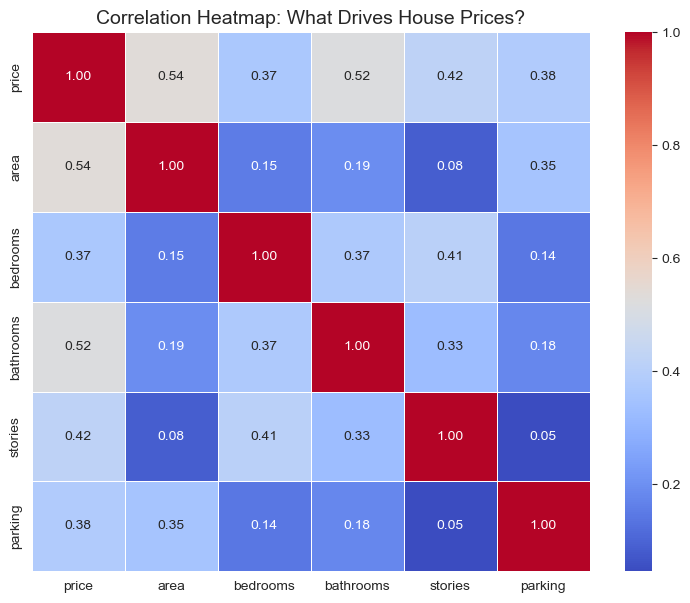

In [17]:
# Correlation matrix of all numeric drivers
numerical_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
plt.figure(figsize=(9, 7))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: What Drives House Prices?', fontsize=14)
plt.show()

### Correlation Heatmap: Key Price Drivers

* **Top Price Drivers:** `area` (**0.54**) and `bathrooms` (**0.52**) show the strongest positive correlation with `price`.
* **Secondary Influences:** `stories` (**0.42**), `parking` (**0.38**), and `bedrooms` (**0.37**) have moderate positive relationships with `price`.
* **Feature Relationships:** The strongest non-price correlation is between `bedrooms` and `stories` (**0.41**), indicating taller houses generally have more rooms.
* **Multicollinearity Check:** Most feature-to-feature correlations remain low-to-moderate (under 0.41), suggesting low risk of severe multicollinearity for linear modeling.


### Summary of Insights & Recommendations

1. **Top Value Drivers:** Property size (`area`) and `bathrooms` hold the strongest correlation with `price`. Focus heavily on these two assets for valuation models.
2. **Core Market Core:** The inventory heavily favors **3-bedroom, 1-bathroom, 1-to-2-story** homes. These represent the highest density and most predictable price points.
3. **Subdivision Cap:** Adding bedrooms yields consistent returns up to 5 rooms, but drops at 6. Buyers prioritize total spatial area over excessive room counts.
4. **Premium Upgrade Lift:** While main road access is standard, luxury features like **air conditioning** are rare, serving as high-leverage assets for premium pricing.
5. **Data Prep Rule:** Heavy right-skewness and extreme spatial outliers (10,500+ sq. ft.) dictate using **log-transformations** or outlier removal before linear modeling.
